<a href="https://colab.research.google.com/github/itsarifworld/randoms/blob/main/naive_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['Label', 'Message']
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

print(df.head())

   Label                                            Message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [6]:
X = df['Message']
y = df['Label']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# CONVERT TEXT DATA INTO NUMERICAL FORM
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)

# Only transform test data
X_test_vec = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9838565022421525
Confusion Matrix:
 [[963   2]
 [ 16 134]]


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Confusion Matrix')

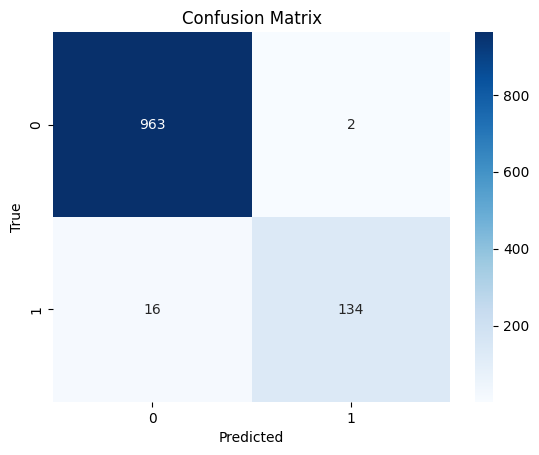

In [17]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

In [18]:
# TEST MODEL ON NEW MESSAGES
new_messages = [
    "Congratulations! You won a free ticket.",
    "Hey, are we still meeting today?"
]

new_vec = vectorizer.transform(new_messages)
predictions = nb_model.predict(new_vec)

for message, prediction in zip(new_messages, predictions):
    print(f"Message: {message}\nPrediction: {'Spam' if prediction == 1 else 'Ham'}\n")

Message: Congratulations! You won a free ticket.
Prediction: Spam

Message: Hey, are we still meeting today?
Prediction: Ham

